In [1]:
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt 


In [2]:
df = pd.read_csv("spamraw.csv")

df.head()

,type,text
0,ham,Hope you are having a good week. Just checking in
1,ham,K..give back my thanks.
2,ham,Am also doing in cbe only. But have to pay.
3,spam,"complimentary 4 STAR Ibiza Holiday or £10,000 ..."
4,spam,okmail: Dear Dave this is your final notice to...


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])

df.head()

,type,text
0,0,Hope you are having a good week. Just checking in
1,0,K..give back my thanks.
2,0,Am also doing in cbe only. But have to pay.
3,1,"complimentary 4 STAR Ibiza Holiday or £10,000 ..."
4,1,okmail: Dear Dave this is your final notice to...


In [4]:
print(df.isna().sum())
print(df.duplicated().sum())

type    0
text    0
dtype: int64
403


In [5]:
df.drop_duplicates(keep='first')

,type,text
0,0,Hope you are having a good week. Just checking in
1,0,K..give back my thanks.
2,0,Am also doing in cbe only. But have to pay.
3,1,"complimentary 4 STAR Ibiza Holiday or £10,000 ..."
4,1,okmail: Dear Dave this is your final notice to...
...,...,...
5554,0,You are a great role model. You are giving so ...
5555,0,"Awesome, I remember the last time we got someb..."
5556,1,"If you don't, your prize will go to another cu..."
5557,1,"SMS. ac JSco: Energy is high, but u may not kn..."


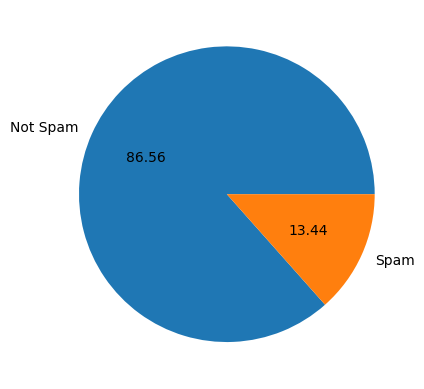

In [6]:
plt.pie(df["type"].value_counts(), labels=["Not Spam", "Spam"], autopct="%0.2f")
plt.show()

In [7]:
import nltk

In [8]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Aayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Aayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [9]:
df.columns

Index(['type', 'text'], dtype='object')

In [10]:
df['num_char'] = df['text'].apply(len)
df.head()

,type,text,num_char
0,0,Hope you are having a good week. Just checking in,49
1,0,K..give back my thanks.,23
2,0,Am also doing in cbe only. But have to pay.,43
3,1,"complimentary 4 STAR Ibiza Holiday or £10,000 ...",149
4,1,okmail: Dear Dave this is your final notice to...,161


In [11]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

,type,text,num_char,num_words
0,0,Hope you are having a good week. Just checking in,49,11
1,0,K..give back my thanks.,23,7
2,0,Am also doing in cbe only. But have to pay.,43,12
3,1,"complimentary 4 STAR Ibiza Holiday or £10,000 ...",149,23
4,1,okmail: Dear Dave this is your final notice to...,161,32


In [12]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,type,text,num_char,num_words,num_sentences
0,0,Hope you are having a good week. Just checking in,49,11,2
1,0,K..give back my thanks.,23,7,1
2,0,Am also doing in cbe only. But have to pay.,43,12,2
3,1,"complimentary 4 STAR Ibiza Holiday or £10,000 ...",149,23,3
4,1,okmail: Dear Dave this is your final notice to...,161,32,3


In [13]:
import seaborn as sns

<Axes: >

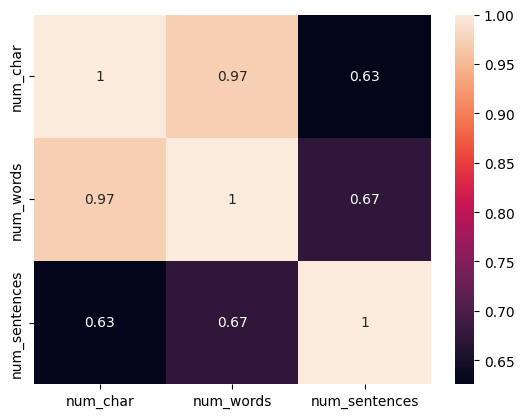

In [14]:
sns.heatmap(df[['num_char', 'num_words', 'num_sentences']].corr(), annot=True)

In [15]:
def lower_text(string):
    string = string.apply(lambda x: x.lower())

    return string

In [16]:
def create_tokens(string):
    return string.apply(lambda x: nltk.word_tokenize(x))

In [17]:
def remove_special(tokens):
    return tokens.apply(lambda tokens: [i for i in tokens if i.isalnum()])

In [18]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(refined):
    return refined.apply(lambda words: [i for i in words if i not in stop_words])

In [19]:
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()

def use_stem(string):
    return string.apply(lambda base_word: [stemmer.stem(i) for i in base_word ])

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

data_pipeline = Pipeline([
    ('lowercase', FunctionTransformer(lower_text)),
    ('tokenize_words', FunctionTransformer(create_tokens)),
    ('remove_special', FunctionTransformer(remove_special)),
    ('remove_stopwords', FunctionTransformer(remove_stopwords)),
    ('Use_PorterStemmer', FunctionTransformer(use_stem))
])

In [21]:
df["transformed_text"] = data_pipeline.fit_transform(df['text'])
df['transformed_text'] = df['transformed_text'].apply(' '.join)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_text'])
y = df['type']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

svm = LinearSVC(max_iter=1000)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\n\t\t\t\t\t-:- For Logistic Regression -:-\n")
print(f"The Accuracy Score is: \n {accuracy_score(y_test, y_pred_lr)}")
print(f"\nThe Confusion Matrix is: \n {confusion_matrix(y_test, y_pred_lr)}")
print(f"\nThe Classification Report is: \n {classification_report(y_test, y_pred_lr)}")

print("\t\t\t\t\t-:- For Multinomial Naive Bayes -:-\n")
print(f"The Accuracy Score is: \n {accuracy_score(y_test, y_pred_nb)}")
print(f"\nThe Confusion Matrix is: \n {confusion_matrix(y_test, y_pred_nb)}")
print(f"\nThe Classification Report is: \n {classification_report(y_test, y_pred_nb)}")

print("\t\t\t\t\t-:- For Linear Support Vector Classifier -:-\n")
print(f"The Accuracy Score is: \n {accuracy_score(y_test, y_pred_svm)}")
print(f"\nThe Confusion Matrix is: \n {confusion_matrix(y_test, y_pred_svm)}")
print(f"\nThe Classification Report is: \n {classification_report(y_test, y_pred_svm)}")


					-:- For Logistic Regression -:-

The Accuracy Score is: 
 0.9594039054470709

The Confusion Matrix is: 
 [[1684    5]
 [  74  183]]

The Classification Report is: 
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      1689
           1       0.97      0.71      0.82       257

    accuracy                           0.96      1946
   macro avg       0.97      0.85      0.90      1946
weighted avg       0.96      0.96      0.96      1946

					-:- For Multinomial Naive Bayes -:-

The Accuracy Score is: 
 0.9707091469681398

The Confusion Matrix is: 
 [[1687    2]
 [  55  202]]

The Classification Report is: 
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1689
           1       0.99      0.79      0.88       257

    accuracy                           0.97      1946
   macro avg       0.98      0.89      0.93      1946
weighted avg       0.97      0.97      0.97      1946

	

In [24]:
results = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'MultinomialNB': accuracy_score(y_test, y_pred_nb),
    'LinearSVC': accuracy_score(y_test, y_pred_svm)
}

best_model = max(results, key=results.get)
print(f"Best Model: {best_model} with accuracy {results[best_model]:.4f}")

Best Model: LinearSVC with accuracy 0.9753


In [25]:
import pickle
import os

os.makedirs('models', exist_ok=True)

with open('models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('models/nb_model.pkl', 'wb') as f:
    pickle.dump(nb, f)

with open('models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

with open('models/tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Saved: lr, nb, svm, tfidf")

Saved: lr, nb, svm, tfidf
